# 02 · Forecast the next 12 weeks per region
Models compared with a **rolling-origin backtest** (4 folds × 12 weeks = 48 out-of-sample weeks per region):

| Model | Notes |
|---|---|
| Seasonal naive | same week last year — the bar any real model must beat |
| ARIMA(1,1,1) + Fourier(K=4) | log-demand, yearly seasonality via Fourier terms (statsmodels) |
| Prophet | trend + yearly seasonality, multiplicative |

Metric: **MAPE** (plus WAPE and bias). Code: `src/forecast.py`.

In [1]:
import pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image
acc = pd.read_csv("../data/processed/forecast_accuracy.csv")
acc.pivot(index="region", columns="model", values="MAPE_%").assign(best=lambda d: d.drop(columns="Seasonal naive").idxmin(axis=1))

model,ARIMA+Fourier,Prophet,Seasonal naive,best
region,,,,
Midwest,8.96,8.75,13.11,Prophet
South,4.65,4.14,5.63,Prophet
West,3.91,4.75,10.29,ARIMA+Fourier


In [2]:
print("Overall MAPE across all regions/folds:")
bt = pd.read_csv("../data/processed/backtest_predictions.csv")
import numpy as np
print(bt.dropna().groupby("model").apply(lambda d: (abs(d.actual-d.forecast)/d.actual).mean()*100).round(2))
acc.pivot(index="region", columns="model", values="bias_%")

Overall MAPE across all regions/folds:
model
ARIMA+Fourier     5.84
Prophet           5.88
Seasonal naive    9.68
dtype: float64


model,ARIMA+Fourier,Prophet,Seasonal naive
region,,,
Midwest,-5.88,-6.75,-13.53
South,-1.72,-1.07,-5.49
West,-2.94,-4.04,-10.35


Both models cut error by ~40% versus seasonal naive (≈5.8% vs 9.7%). **West** is best with ARIMA+Fourier (3.9%), **South/Midwest** with Prophet (4.1% / 8.8%). Midwest is hardest: it has been growing fast, and every model under-forecasts it (bias −6% to −7%, shown below). I pick the best model per region and quote its backtest error as the uncertainty band.

In [3]:
acc.pivot(index="region", columns="model", values="bias_%")  # negative = under-forecast

model,ARIMA+Fourier,Prophet,Seasonal naive
region,,,
Midwest,-5.88,-6.75,-13.53
South,-1.72,-1.07,-5.49
West,-2.94,-4.04,-10.35


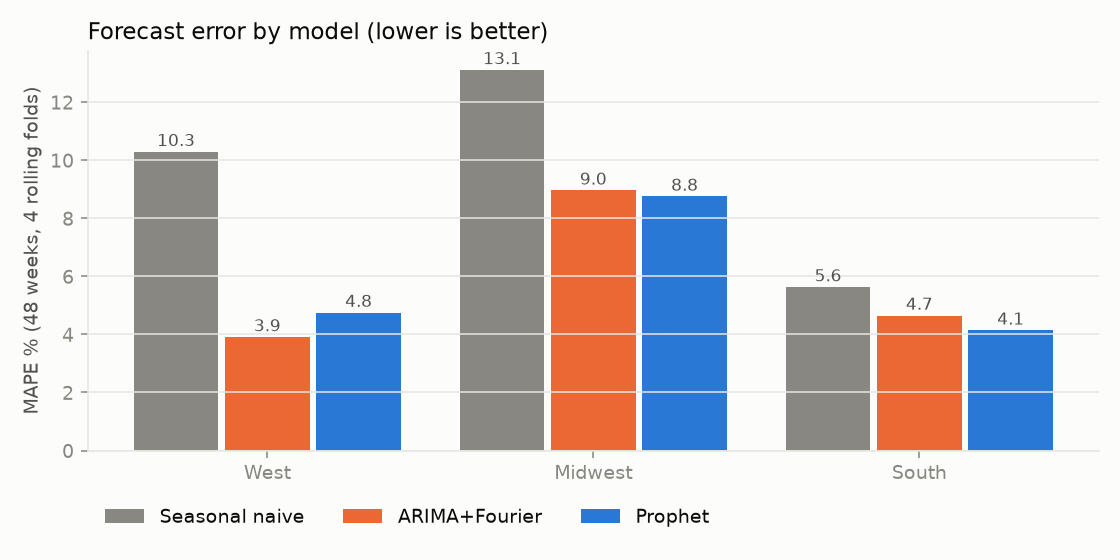

In [4]:
Image("../assets/05_model_mape.png")

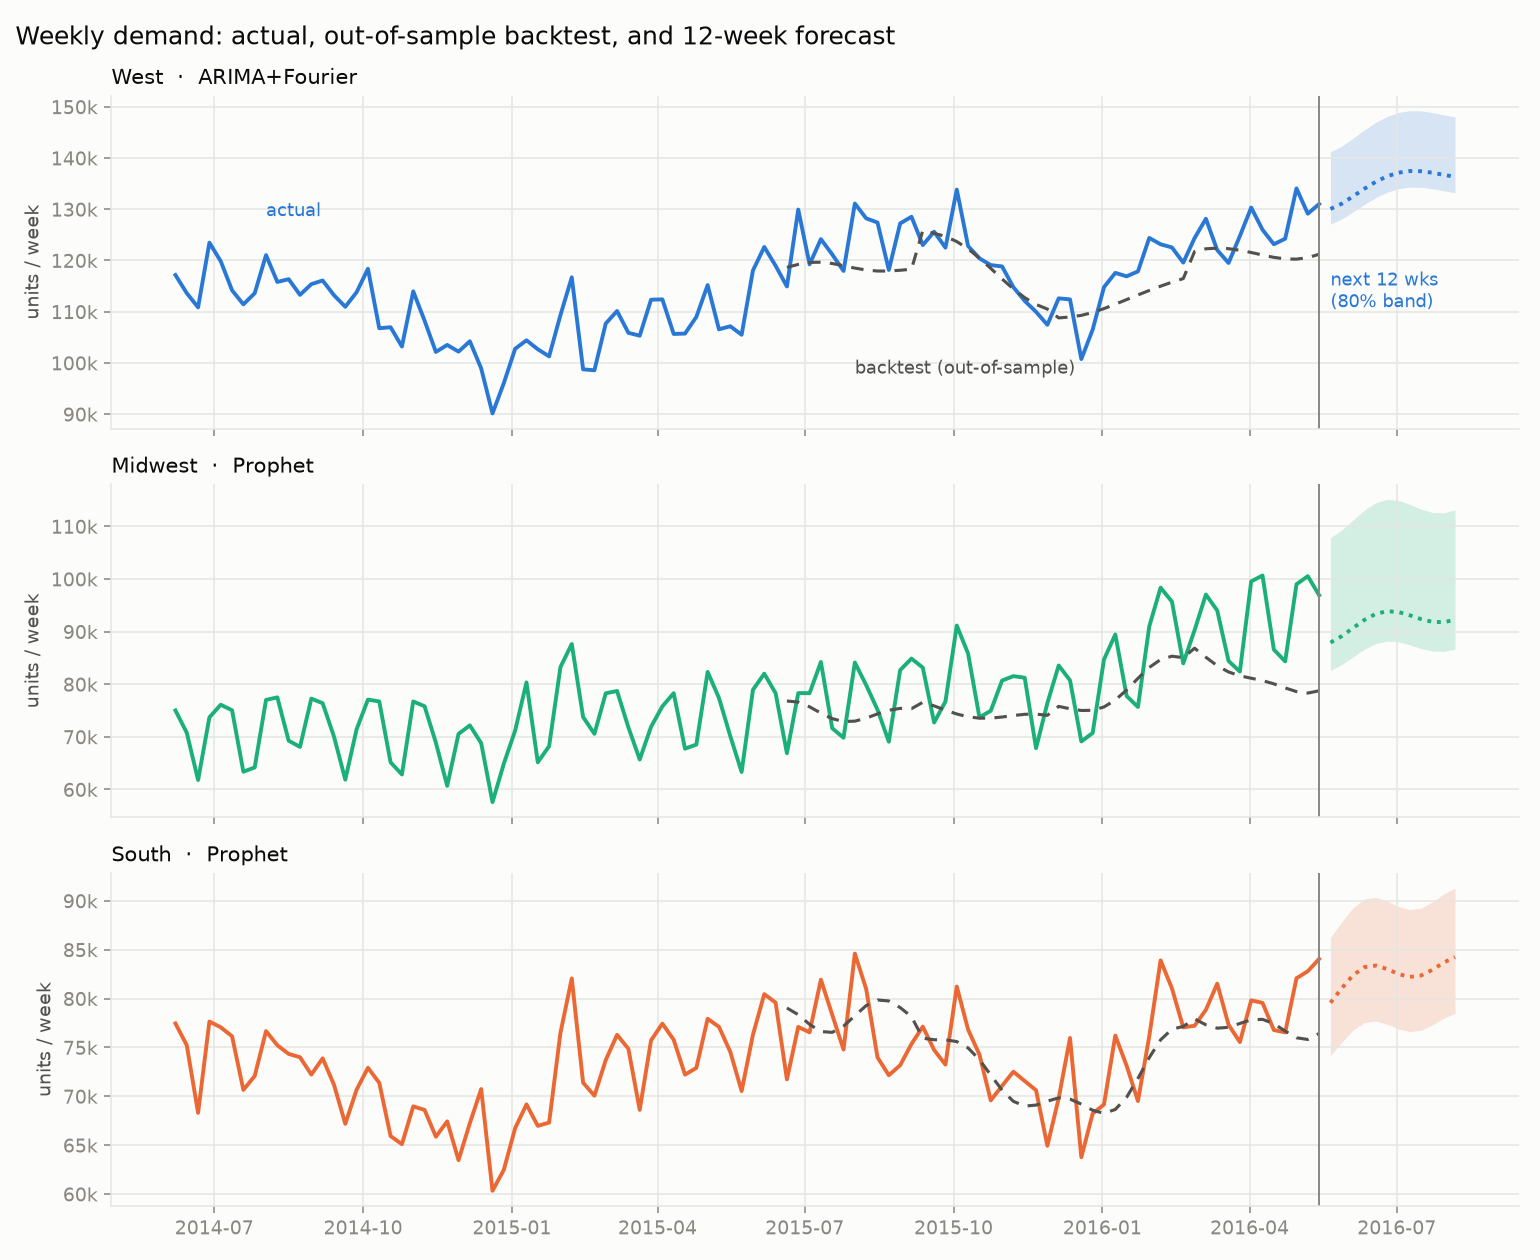

In [5]:
Image("../assets/04_forecast_vs_actual.png")

In [6]:
fc = pd.read_csv("../data/processed/forecast_next_12_weeks.csv", parse_dates=["week_start"])
fc.groupby("region").agg(model=("model","first"), start=("week_start","min"), end=("week_start","max"),
                         total_12wk=("forecast","sum"), avg_week=("forecast","mean"), upper_80_total=("upper_80","sum")).round(0)

/var/folders/sy/rj8mv_411rb79kf75_qwk3wr0000gn/T/ipykernel_10211/2219205647.py:3: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  total_12wk=("forecast","sum"), avg_week=("forecast","mean"), upper_80_total=("upper_80","sum")).round(0)


,model,start,end,total_12wk,avg_week,upper_80_total
region,,,,,,
Midwest,Prophet,2016-05-21,2016-08-06,1102252.0,91854.0,1351773.0
South,Prophet,2016-05-21,2016-08-06,990538.0,82545.0,1073533.0
West,ARIMA+Fourier,2016-05-21,2016-08-06,1621596.0,135133.0,1760520.0


**Caveat:** the 80% band is empirical (from backtest error ratios), not model-based. The upper band is used as the **high-demand stress case** in Part 3.